## Setup

### Change the location to where the dataset is located

In [1]:
import os
os.chdir('../..')
print(f"Changed directory to {os.getcwd()}")

Changed directory to /Users/manu/lib/NMF_github


### Import GeneData.py file where all the functions are defined

In [2]:
from GeneData import * 

Matplotlib is building the font cache; this may take a moment.


## Read and load RNA-Seq gene expression data 

Data is assumed to be in a CSV file in "long" format. There is one row for each combination of transcript and condition/time point.

In [3]:
data = Load_Dataset('example/Repele2605/Repele2605RNASeqTimeSeries.csv')  

Extract gene names by subsetting a combination of condition and time points that ensures unique names.

In [17]:
time = data["timepoints"] == -48       # numpy ndarray and returns a list of booleans for the locations where timepoints == -48 is True and False elsewhere
cond = data["condition"] == "GCSF-OHT" # returns a list of booleans for the locations where condition == 'GCSF-OHT'
GList= np.logical_and(time, cond)      # GList is an boolean numpy ndarray for the GCSF_OHT condition at -48 timepoint
geneNames = data["geneNames"][GList].tolist()    # TotGlist is an numpy array containing all the gene names(36255)
gcsf = exprs(TotGList , 'GCSF-OHT' , data, False)   #Timepoints and expression values for genes in the  total list("TotGList") with GCSF-OHT treatment
il3 = exprs(TotGList , 'IL3-OHT' , data, False)     #Timepoints and expression values for genes in the total list("TotGList") with IL3-OHT treatment

Join the expression data from GCSF and IL3 conditions to make the $X_{gt}$ matrix and transpose it so that rows are transcripts and columns are conditions/timepoints.

In [18]:
Xgt = np.concatenate((gcsf[1], il3[1]), 0)
Xgt = Xgt.T

### Filter out genes whose maximum expression is less than a given threshold

In [19]:
XgtFilt, geneNamesFilt = filter_low_expressing_genes(Xgt, geneNames, 5.0)

### Scale gene expression on a [0,1] scale

In [20]:
XgtFiltScaled = scaleGeneExpression(XgtFilt)

## Perform Non-negative matrix factorization (NMF)

### Run NMF for 10 metagenes

iteration=361   FrobNorm=72.5239510968439


Text(0.5, 1.0, 'Convergence of Frobenius norm')

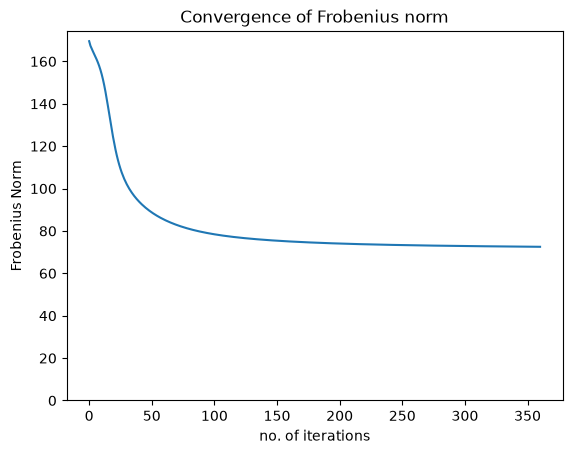

In [21]:
Wgm,Hmt,frobNorm = NMF(XgtFiltScaled, 10 , 0.005) 
plt.plot(frobNorm) ; plt.ylim(bottom=0); plt.xlabel("no. of iterations"); plt.ylabel("Frobenius Norm");plt.title("Convergence of Frobenius norm") 

### Write the $Wgm$, $Hmt$, $Xgt$ (filtered and scaled) matrices, and the filtered gene names to csv files

In [22]:
with open('example/Repele2605/Wgm.csv' , 'w',  newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["1","2","3","4","5","6","7","8","9","10"])
    writer.writerows(Wgm)
with open('example/Repele2605/Hmt.csv' , 'w',  newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["-48","0","1","2","3","4","8","12","16","20","24","32","40","48","56","64","72","80","88","96","104","112","120","128","136","144","152","160","168","0","1","2","3","4","8","12","16","20","24","32","40","48","56","64","72","80","88","104","112","120","128","136","152","160","168"])
    writer.writerows(Hmt)
with open('example/Repele2605/XgtFiltScaled.csv' , 'w',  newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["-48","0","1","2","3","4","8","12","16","20","24","32","40","48","56","64","72","80","88","96","104","112","120","128","136","144","152","160","168","0","1","2","3","4","8","12","16","20","24","32","40","48","56","64","72","80","88","104","112","120","128","136","152","160","168"])
    writer.writerows(Xgt)
geneNamesFiltArr = np.array(geneNamesFilt)
np.savetxt('example/Repele2605/geneNamesFilt.txt', geneNamesFiltArr, fmt="%s")

## Visualize NMF in 3D

### Sort Hmt and perform normalization. (These normalized Hmt values can be used for 3D visualization with any sorting method)

In [23]:
WgmSorted, HmtSorted, Hmt_beh_idx = sorted_Hmt_behaviors(Hmt, Wgm)

#Assign sorted Hmt behaviors for two conditions separately
GCSF_sorted_Hmt = HmtSorted[:,:29]
IL3_sorted_Hmt = HmtSorted[:,29:]

### Perform nested sorting

In [24]:
nested_sort_both_conditions = NMF_nested_sort(XgtFiltScaled, WgmSorted, HmtSorted, geneNamesFilt)


### Assign nested sorted Xgt values to variables for two conditions separately
GCSF_nested_sorted_Xgt = nested_sort_both_conditions[0][:,:29]
IL3_nested_sorted_Xgt = nested_sort_both_conditions[0][:,29:]
Wgm_nested_sorted = nested_sort_both_conditions[1]
Hmt_nested_sorted = nested_sort_both_conditions[2]
sorted_indices = nested_sort_both_conditions[3]
sorted_gene_names = nested_sort_both_conditions[4]

### Visualize in 3D

#### GCSF

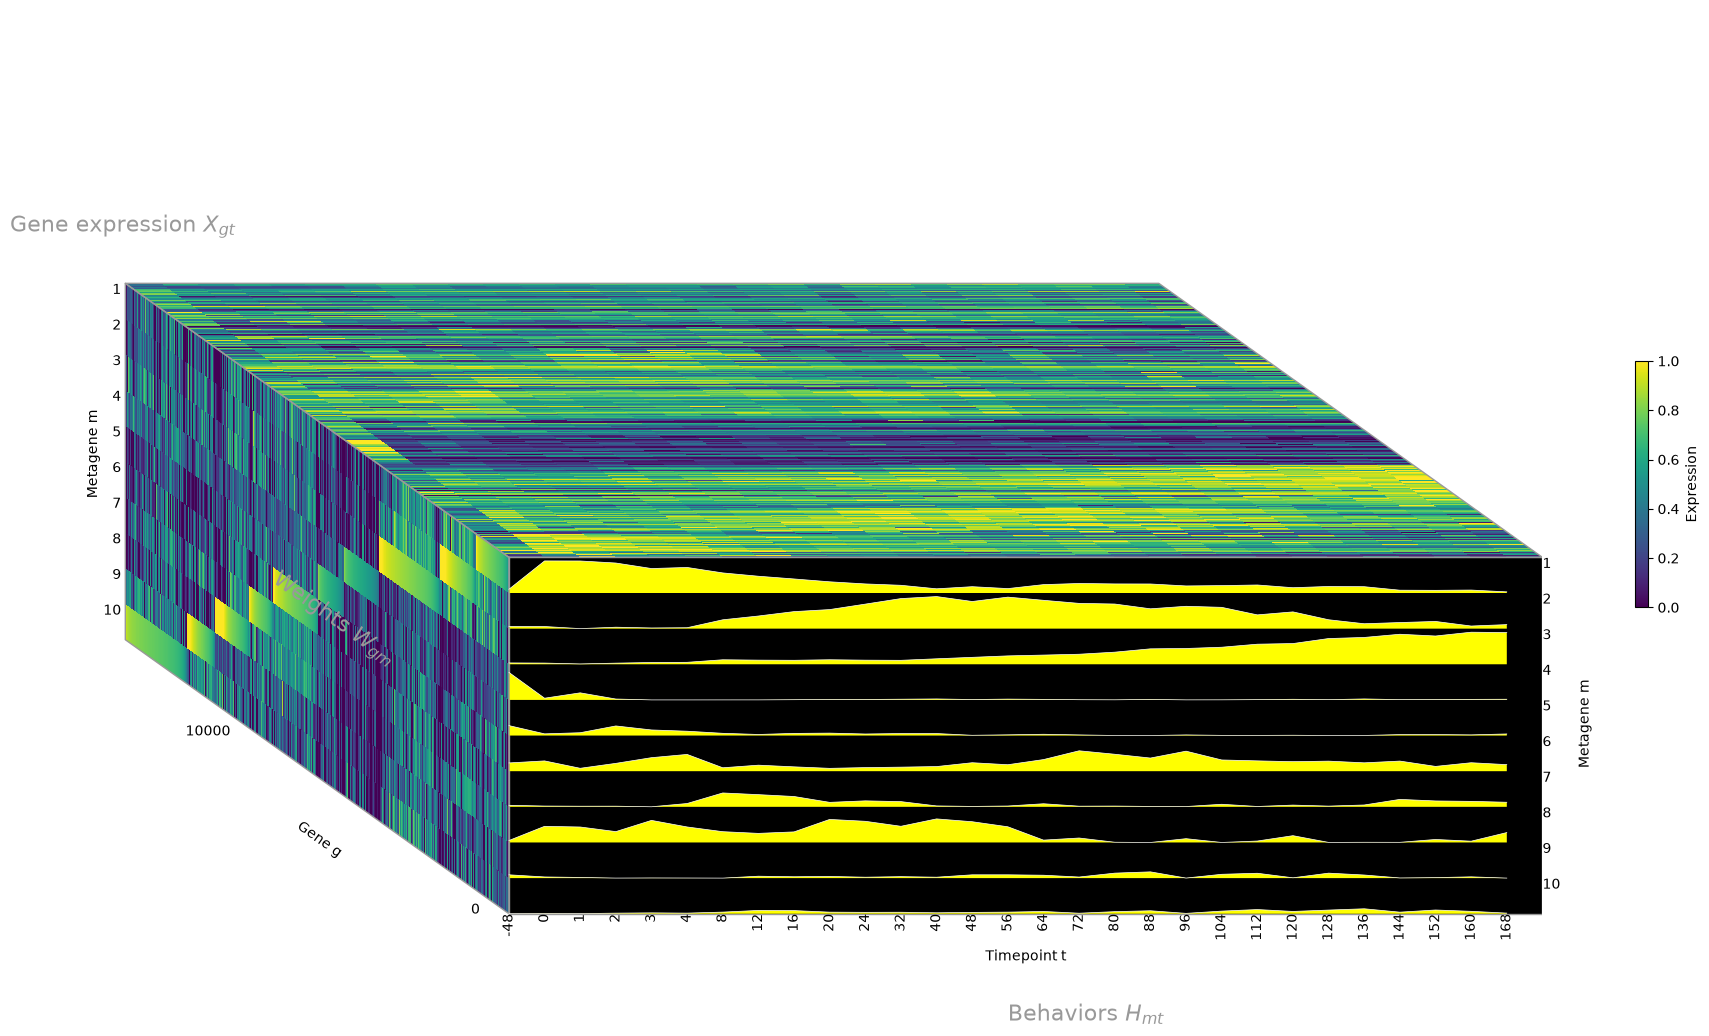

In [25]:
GCSF_sort_visualization = NMF_sorted_visualization(GCSF_nested_sorted_Xgt, Wgm_nested_sorted, GCSF_sorted_Hmt, gcsf[0],'example/Repele2605/NMF3DFilteredGCSF.png')

Save the plot.

In [26]:
GCSF_sort_visualization.savefig('example/Repele2605/NMF3DFilteredGCSF.png', bbox_inches='tight', dpi=300)

#### IL3

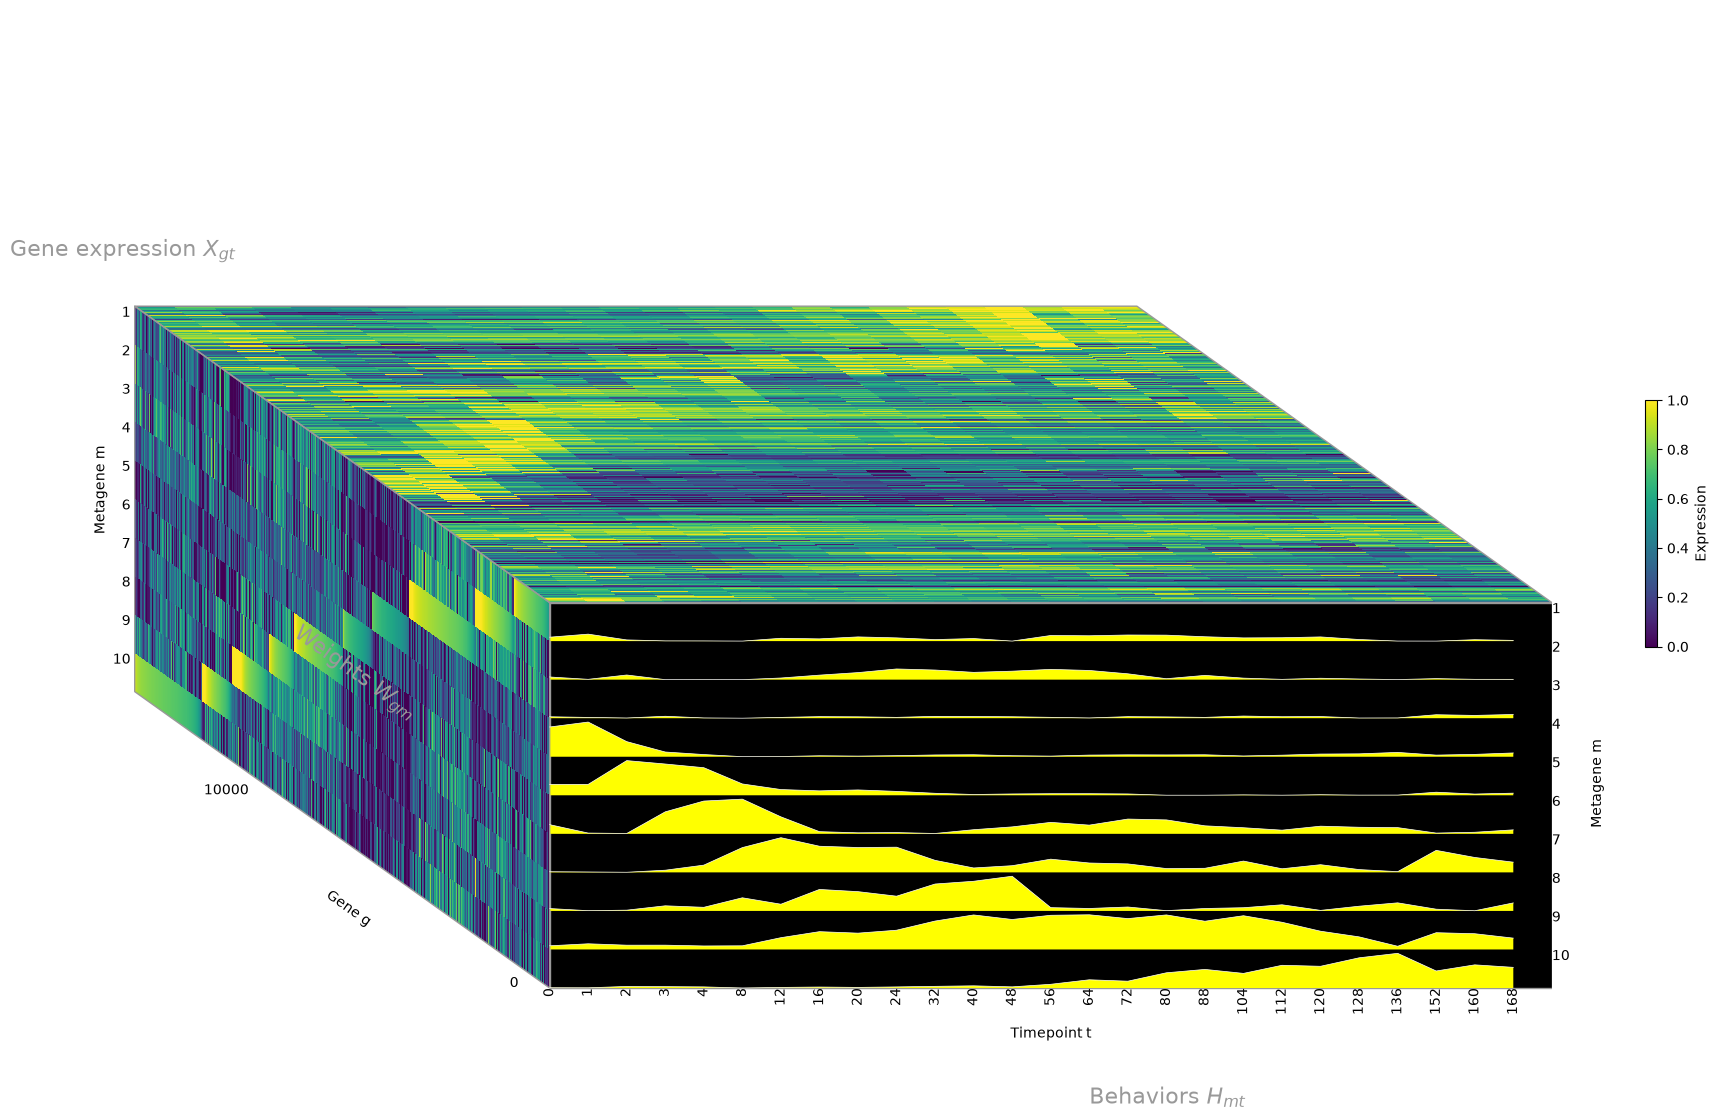

In [27]:
IL3_sort_visualization = NMF_sorted_visualization(IL3_nested_sorted_Xgt, Wgm_nested_sorted, IL3_sorted_Hmt, il3[0], 'example/Repele2605/NMF3DFilteredIL3.png')

Save the plot.

In [28]:
IL3_sort_visualization.savefig('example/Repele2605/NMF3DFilteredIL3.png', bbox_inches='tight', dpi=300)